### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2025-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

- Pierre Marrec -- `pierre.marrec@inria.fr`

***

### ⚠️ General guidelines for TPs

The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP2: Principal components regression in genetics

The goal of this TP session is to use genetic markers to predict the geographical origin of a set of indians from South, Central, and North America. We propose to build two regression linear models to predict the latitude and longitude of an individual based on its genetic markers. Because the number of markers (p = 5709) is larger than the number of samples (N = 494), the predictors of the regression model will be the outputs of a principal component analysis (PCA) performed on the genetic markers. A genetic marker is encoded 1 if the individual has a mutation, 0 elsewhere.

## ▶️ Exercise 1: Data visualization (1 point)

NB: To do this exercise you will have to install packages `geopandas` and `geodatasets`.

Download dataset `NAm2.txt` from [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP2/NAm2.txt). Each row of the dataset corresponds to an individual and the columns have explicit names. The third column contains the names of the tribes to which each individual pertains. Columns 7 and 8 contain the latitude and the longitude and from Column 9 onwards are genetic markers, which are encoded are 0 or 1. Run the code described below and explain how it works.


In [1]:
#imports
import numpy as np
import pandas as pd
import geopandas as gpd
import geodatasets
import matplotlib.pyplot as plt
import sklearn
import sklearn.linear_model as sl
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_validate, GroupKFold
from sklearn.metrics import make_scorer


/tmp/ipykernel_16984/900605043.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


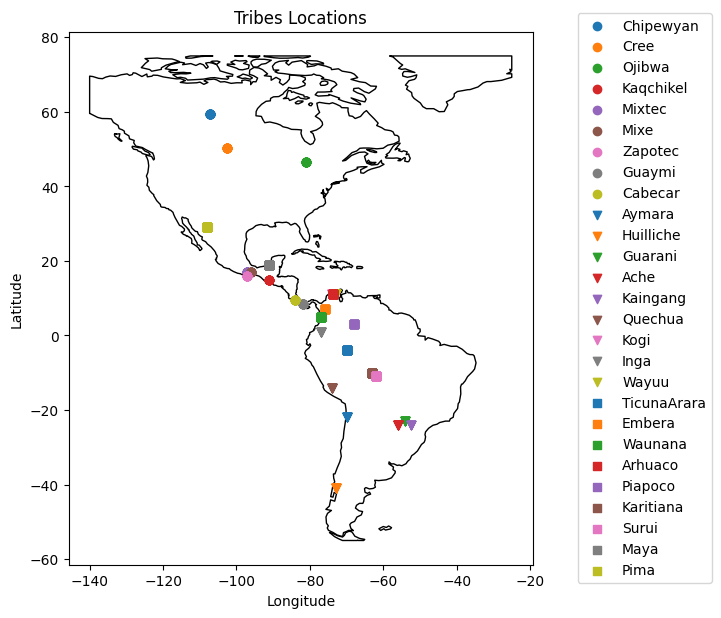

In [2]:
# Load the data
file_path = 'NAm2.txt'
df = pd.read_csv(file_path, delimiter=' ')

# Extract relevant columns
latitude = df.iloc[:, 6]
longitude = df.iloc[:, 7]
tribes = df.iloc[:, 2]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(longitude, latitude))

# Plotting
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
for i, tribe in enumerate(gdf['Pop'].unique()):
    members_tribe = gdf[gdf['Pop'] == tribe] # creates a filtered GeoDataFrame for the current tribe
    ax.scatter(members_tribe['long'], members_tribe['lat'], # plots the locations of the members of the current tribe using the longitude and latitude columns
               marker=marker_list[i//9], 
               color=colors_list[i%9], label=tribe)
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Tribes Locations')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The code first loads the dataset into a DataFrame `df`, where each row is an individual.  
It extracts latitude (`lat`), longitude (`long`), and tribe (`Pop`) information, then builds a `GeoDataFrame` by converting each `(longitude, latitude)` pair into a geographic point.

A map background (`naturalearth.land`) is loaded and clipped to the Americas area.  
Then, for each tribe, the code filters the corresponding individuals and plots their coordinates with a specific marker/color combination.  
Finally, it adds a legend, title, and axis labels to make the map interpretable.

So the figure visualizes the geographic distribution of individuals by tribe, showing how populations are spatially organized.

In [3]:
df

,IndivID,PopID,Pop,Country,Continent,sex,lat,long,L1.125,L1.130,...,L677.255.553287981859,L677.259,L677.263,L677.267,L678.202,L678.206,L678.209.848101265823,L678.210,L678.214,L678.218
Chipewyan29,2012,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan31,2156,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,1,0,0,0
Chipewyan33,2381,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,1,0,0,0,0
Chipewyan35,2382,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,0,0,0,0,0,0,1,0,0
Chipewyan37,2383,811,Chipewyan,Canada,AMERICA,0,59.55,-107.3,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Pima1043,1057,87,Pima,Mexico,AMERICA,0,29.00,-108.0,0,0,...,0,0,1,0,0,0,0,1,0,0
Pima1045,1058,87,Pima,Mexico,AMERICA,0,29.00,-108.0,0,0,...,0,0,1,0,0,0,0,1,0,0
Pima1047,1059,87,Pima,Mexico,AMERICA,0,29.00,-108.0,0,0,...,0,0,0,0,0,0,0,1,0,0
Pima1049,1060,87,Pima,Mexico,AMERICA,0,29.00,-108.0,0,0,...,0,1,0,0,0,0,0,1,0,0


## ▶️ Exercise 2: Multiple linear regression (2 points)

Using **only** the genetic markers as predictors, you will estimate a multiple linear regression model to predict the longitude of each individual.

You will proceed in several steps.

**(a)** First, try to estimate the coefficients of the multiple linear regression using the expression seen in class 

$$\hat{\beta} = (X^\top X)^{-1}X^\top y$$

You should proceed as we did in TP1 using `numpy.linalg.solve` to obtain the values of $\beta$. 

Did you run into any errors? What is going on? Relate your answer to the fact that $\text{rank}(X) < p$, where $X \in R^{N*p}$ is the data matrix.

In [4]:
X = df.iloc[:, 8:].values  # genetic markers as predictors 
y = df.iloc[:, 7].values   # Longitude as target variable
try:
    beta_hat = np.linalg.solve(X.T @ X, X.T @ y)
except np.linalg.LinAlgError:
    print("Matrix X^T X is singular, cannot compute beta_hat using np.linalg.solve.")

Matrix X^T X is singular, cannot compute beta_hat using np.linalg.solve.


**Answer (a):** Running `numpy.linalg.solve(X.T @ X, X.T @ y)` raises a `LinAlgError: Singular matrix` error. The root cause is that we have $N = 494$ individuals but $p = 5709$ genetic markers, so $N < p$. The matrix $X^{\top}X$ is $p \times p$ but has rank at most $\min(N, p) = N = 494 < p$, making it singular and non-invertible. Having more features than samples means the system is underdetermined; thus, there are infinitely many $\hat\beta$ that perfectly fit the data.

**(b)** Use function `numpy.linalg.lstsq` to estimate the coefficients (it may take a few seconds to get a result). 

And now? Did you get any errors? Why is that? 

Relate your answer to the difference between functions `numpy.linalg.solve` and `numpy.linalg.lstsq`.

You can check the documention for both functions as well as [this](https://netlib.org/lapack/lug/node27.html) link for more information.

In [5]:
np.linalg.lstsq(X, y, rcond=None)[0]

array([-0.04005781, -0.01940898,  0.01111306, ..., -0.21729626,
       -0.10210421,  0.01813644], shape=(5709,))

**Answer (b):** No error is raised this time. Unlike `numpy.linalg.solve`, which requires a square, full-rank matrix to compute an exact inverse, `numpy.linalg.lstsq` instead searches for the least squares solution $\min \lVert y - Xx \rVert_2$ using SVD or orthogonal decomposition, and returns the one with the minimum norm $\min \lVert x \rVert_2$.

 **(c)** We will now use `sklearn` to do our linear regression with the help of class `sklearn.linear_model.LinearRegression` whose documentation is available [here](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LinearRegression.html). Note that every estimator from `sklearn` has a `fit` and a `predict` method, which are used to calculate coefficients and predict values (see [here](https://scikit-learn.org/stable/getting_started.html#fitting-and-predicting-estimator-basics) for more info). In our current case, we can do:

You should not run into errors now, since `sklearn` also uses `lstsq` to solve the normal equations, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L682) (though it uses the `scipy` implementation instead of the `numpy` for "historical" reasons). Check the values of the estimated coefficients stored as an attribute in `lr.coef_`, are they the same as the ones obtained in item **(b)**? Probably not. This is because `sklearn` re-centers the predictors before estimating the coefficients of the linear regression, as shown [here](https://github.com/scikit-learn/scikit-learn/blob/d666202a9349893c1bd106cc9ee0ff0a807c7cf3/sklearn/linear_model/_base.py#L622). What would be a practical reason for doing such re-centering systematically? Hint: it has to do with how to interpret the intercept of the model. 

In [6]:
# select only the genetic markers as predictors
predictors = df.columns[8:]
# create the design matrix
X = df[predictors].values
# get the observed values to predict
y = df['long']
# fit a multiple linear regression model
lr = sl.LinearRegression()
lr.fit(X, y)
lr.coef_

array([-0.03940988, -0.0245272 ,  0.01089763, ...,  0.04804479,
       -0.08985062,  0.01903025], shape=(5709,))

**Answer (c):** Re-centering the predictors makes the intercept $\hat\beta_0$ interpretable: it becomes the predicted response for the average individual in the dataset. Without centering, $\hat\beta_0$ would represent the predicted longitude when all genetic markers are 0 simultaneously, which corresponds to an individual with absolutely no mutations. This scenario is unrealistic and meaningless.

## ▶️ Exercise 3: Principal components analysis (5 points)

**(a)** Explain in a few words the main concepts and ideas underlying the principal component analysis (PCA). You should include both the geometric and statistical interpretations of PCA.

PCA is a dimensionality reduction algorithm that computes the principal directions of the data, projecting high-dimensional data onto a lower-dimensional subspace. Statistically, it preserves the maximum amount of variance (information) contained in the data. It achieves this by retaining only the eigenvectors of the covariance matrix corresponding to the largest eigenvalues.

**(b)** Use the estimator defined in `sklearn.decomposition.PCA` to do a PCA on the dataset. Plot the first two dimensions of the projected data points on a scatterplot. The scattered points should have different markers and colors depending on which tribe they belong to. You can use the same color/marker style from **Exercise 2** or propose a new one.

In [7]:
pca1 = PCA()
X_pca1 = pca1.fit_transform(X)

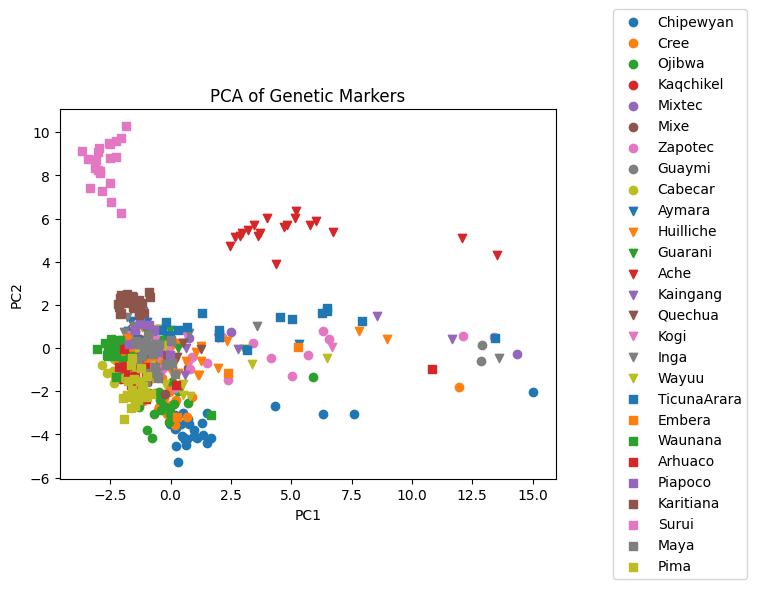

In [8]:
fig, ax = plt.subplots()
for i, tribe in enumerate(df['Pop'].unique()):
    mask = df['Pop'] == tribe
    ax.scatter(X_pca1[mask, 0], X_pca1[mask, 1],
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('PCA of Genetic Markers')
plt.show()

**(c)** Remember from our class that the results of PCA are affected when pre-processing transformations are applied to the data. We will illustrate this using `sklearn.preprocessing.StandardScaler` as per:
```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
```
Redo the 2D scatter plot from item **(b)** on the normalized version of the datast. How does it compare to your previous plot?

In [9]:
scaler = StandardScaler()
scaler.fit(X)
X_std = scaler.transform(X)
pca2 = sklearn.decomposition.PCA()
X_pca2 = pca2.fit_transform(X_std)
pca2.components_

array([[ 1.10298949e-03,  3.80990912e-05,  1.06471682e-02, ...,
        -1.13898532e-02,  5.07926283e-03, -2.40980630e-05],
       [ 3.26537169e-03,  1.27954526e-03,  6.52740578e-03, ...,
         2.10219967e-02,  7.03382825e-03, -1.16131897e-03],
       [ 6.35080151e-03,  5.49160150e-03,  2.28188688e-03, ...,
        -2.63523575e-02,  6.80876201e-03,  5.89828339e-04],
       ...,
       [-2.08906564e-03,  7.13402535e-04, -6.71022963e-04, ...,
         1.92640617e-03,  7.54531396e-03, -9.29169833e-03],
       [ 3.15786790e-03, -6.77517704e-05, -3.81920704e-06, ...,
        -5.23774636e-03, -4.37181395e-03,  7.66201956e-03],
       [ 1.26330686e-01,  2.24451329e-01,  2.56771410e-01, ...,
        -5.60652500e-03,  6.76885371e-03,  1.06284062e-02]],
      shape=(494, 5709))

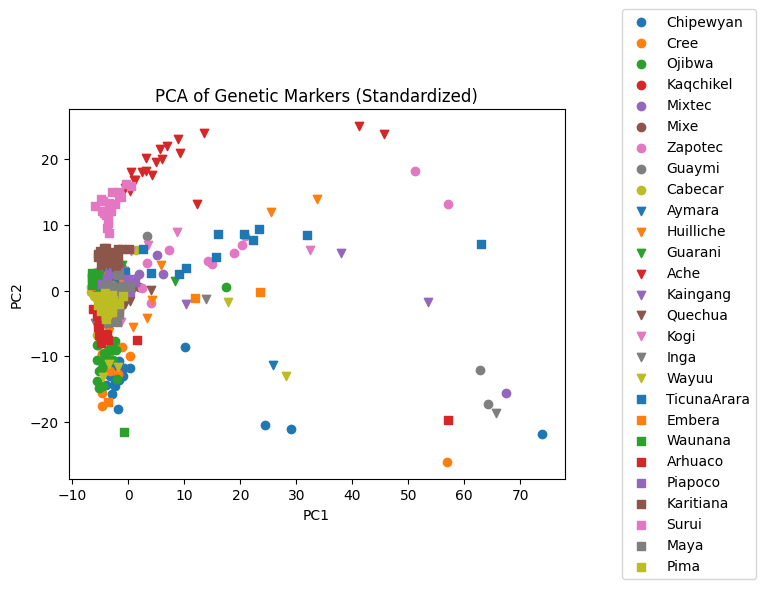

In [10]:
fig, ax = plt.subplots()
for i, tribe in enumerate(df['Pop'].unique()):
    mask = df['Pop'] == tribe
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1], # two first principal components
               marker=marker_list[i//9],
               color=colors_list[i%9], label=tribe)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('PCA of Genetic Markers (Standardized)')
plt.show()

It does not seem to change much; the points still overlap.

**(d)** Given the results in **(b)** and **(c)**, what can you conclude regarding the necessity of standardizing the data points for the dataset consider in this TP?

Standardizing does not visually improve the clustering of the data points, suggesting that this preprocessing step may not be strictly necessary for this dataset.

**(e)** Which percentage of variance is captured by the first two principal components? How many principal components would you keep if you would like to represent the genetic markers using a minimal number of principal components? To help answering this question, you can use a plot showing the cumulative percentage of variance as a function of the number of principal components.

In [11]:
print(f" Variance percentage explained by first two components: {np.sum(pca1.explained_variance_ratio_[:2])*100:.2f}%")

 Variance percentage explained by first two components: 3.57%


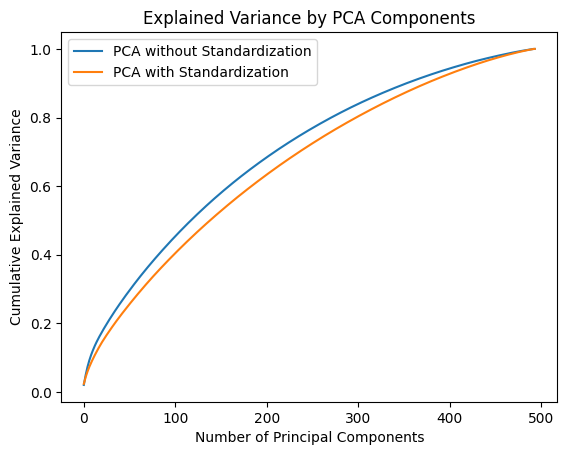

In [12]:
plt.plot(np.cumsum(pca1.explained_variance_ratio_), label='PCA without Standardization')
plt.plot(np.cumsum(pca2.explained_variance_ratio_), label='PCA with Standardization')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.legend()
plt.show()

To capture the maximum variance with a minimum number of components, we should select between 200 and 300 components, as this is where the cumulative variance curve begins to flatten (representing approximately half of the total components). Furthermore, we can observe that standardizing the data penalizes the explained variance of the initial components.

## ▶️ Exercise 4: Principal components regression (4 points)

**(a)** Predict the latitude and the longitude of all points from the dataset using the scores of the first 250 PCA axes. Plot the predicted spatial coordinates using the same style and structure from **Exercise 1** and compare the results from each plot. What can you conclude? Does the new map illustrate somehow too optimistically (or too pessimistically) the ability to find geographical origin of individuals outside the database from its genetic markers? Justify your answer.

In [13]:
pca = PCA(n_components=250).fit(X)
Z = pca.transform(X)   
y = df[['long', 'lat']]

# fit a multiple linear regression model
lr = sl.LinearRegression()
lr.fit(Z, y)
prediction = lr.predict(Z)
prediction.shape

(494, 2)

/tmp/ipykernel_16984/730478570.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


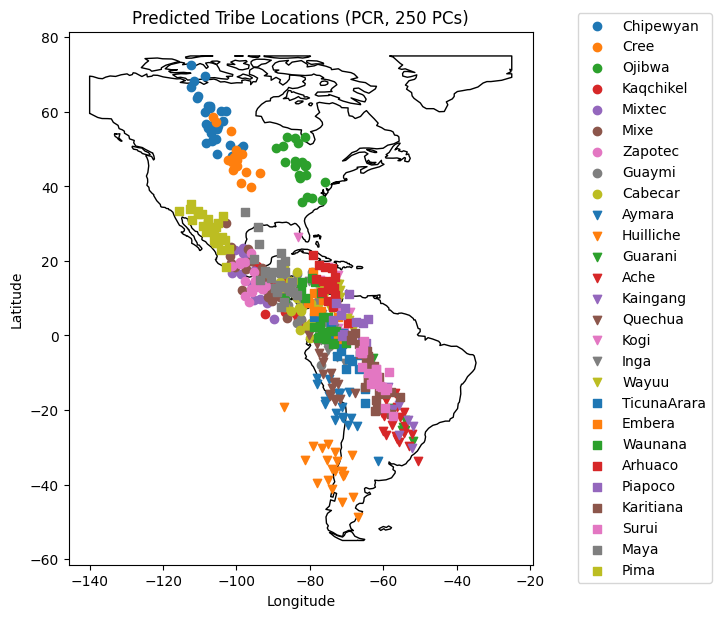

In [14]:
# Plot predicted coordinates
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

unique_tribes = df['Pop'].unique()
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
tribe_styles = {
    tribe: (marker_list[i // 9], colors_list[i % 9])
    for i, tribe in enumerate(unique_tribes)
}

for i in range(len(prediction)):
    tribe = df['Pop'].iloc[i]
    marker, color = tribe_styles[tribe]
    ax.scatter(prediction[i, 0], prediction[i, 1], marker=marker, color=color)

# Build one legend entry per tribe
for tribe in unique_tribes:
    marker, color = tribe_styles[tribe]
    ax.scatter([], [], marker=marker, color=color, label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title('Predicted Tribe Locations (PCR, 250 PCs)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

The points remain close to their true positions and form distinct groups. However, in regions with a high concentration of tribes (such as Central America), many points from different tribes overlap, making it difficult to determine the tribe of a new point. Furthermore, this model is overly optimistic, as it fails to demonstrate how it would perform on unidentified tribes (unseen data).

**(b)** Quantify the error of the linear regression model using the mean distance between real and predicted coordinates. Beware to use `sklearn.metrics.pairwise.haversine_distances` so to correctly measure the distances between points so to take into account the curvature of the Earth. Your answer should be given in kilometers.

In [15]:
# Quantify prediction error with Haversine distance (km) using a loop
distances = []
for pred, true in zip(prediction, y[['long', 'lat']].to_numpy()):
    pred_latlon = np.radians([pred[1], pred[0]])
    true_latlon = np.radians([true[1], true[0]])
    d = 6371.0 * pairwise.haversine_distances([pred_latlon], [true_latlon])[0, 0]
    distances.append(d)

distances = np.array(distances)
print(f"Mean distance error: {distances.mean():.2f} km")
print(f"Max distance error: {distances.max():.2f} km")

Mean distance error: 650.98 km
Max distance error: 3044.39 km


## ▶️ Exercise 5: PCR and cross-validation (6 points)

Our goal now is to build the best model to predict individual geographical coordinates. 

For this, you will run a linear regression to predict latitudes and longitudes. Note that `sklearn.linear_model.LinearRegression` can naturally handle the fact of having two sets of coefficients. We will use ten-fold cross-validation to helps us choose the number of principal axes that we should keep. You should report the errors in terms of kilometers as done in **Exercise 4(b)**.

**(a)** Recall in a few words the principle of cross-validation. Explain why this procedure is useful when building a predictive model. Your answer should mention different strategies to handle datasets in which the samples are not IID.

Cross-validation involves partitioning the dataset into several folds, training the model on some folds, and validating it on the remaining held-out fold. We then average the validation errors across all splits. This approach provides a more robust estimate of the model's generalization performance and helps prevent overfitting during model selection.

When samples are not independent and identically distributed (IID), random splits can cause data leakage because correlated points might appear in both the training and validation sets. In such cases, we should use splitting methods tailored to the data structure, such as `GroupKFold` or `LeaveOneGroupOut` for grouped data, `TimeSeriesSplit` for time-ordered data, or spatial/block cross-validation for geographically correlated samples.  

**(b)** Based on the structure of the dataset being used, such as the different countries of the individuals and the order in which the rows of the dataframe are provided, explain which choice of cross-validation iterator from [here](https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation-iterators) seems the most adequate for our context.

Since the individuals within each tribe are correlated (not independent), we can use the tribes to separate the data into distinct groups. Therefore, `GroupKFold` or a similar group-based iterator is the most appropriate choice.

**(c)** We first assess the quality of the PCR fit for `n_components=4`. Note that you should be careful in avoiding [data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage) problems when doing the PCA followed by a multiple linear regression. You should use the pipeline interface from scikit-learn with `sklearn.pipeline.make_pipeline` to facilitate your task. Be sure to evaluate the errors as done in **Exercise 4(b)**.

In [16]:

def mean_haversine_km(y_true, y_pred):
    earth_radius_km = 6371.0
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    true_latlon = np.radians(y_true[:, [1, 0]])
    pred_latlon = np.radians(y_pred[:, [1, 0]])

    pairwise_rad = pairwise.haversine_distances(pred_latlon, true_latlon)
    return earth_radius_km * np.diag(pairwise_rad).mean()

haversine_km_scorer = make_scorer(mean_haversine_km, greater_is_better=False)

In [17]:
pipeline = make_pipeline(PCA(n_components=4), sl.LinearRegression())
cv = GroupKFold(n_splits=5)
groups = df['Pop']

scores = cross_validate(pipeline, X, y, cv=cv, groups=groups, return_train_score=True, scoring=haversine_km_scorer)
print(f"Mean test score: {-scores['test_score'].mean():.4f}")
print(f"Mean train score: {-scores['train_score'].mean():.4f}")

Mean test score: 2517.8644
Mean train score: 1797.0433


A model with only 4 components generalizes very poorly, as evidenced by the high mean distance error.

**(d)** Repeat the analysis from item **(b)** but changing `n_components` between 2 and 440 in steps of 10. Plot the mean training and test errors versus the number of principal components. Attention, the errors should be given in kilometers.

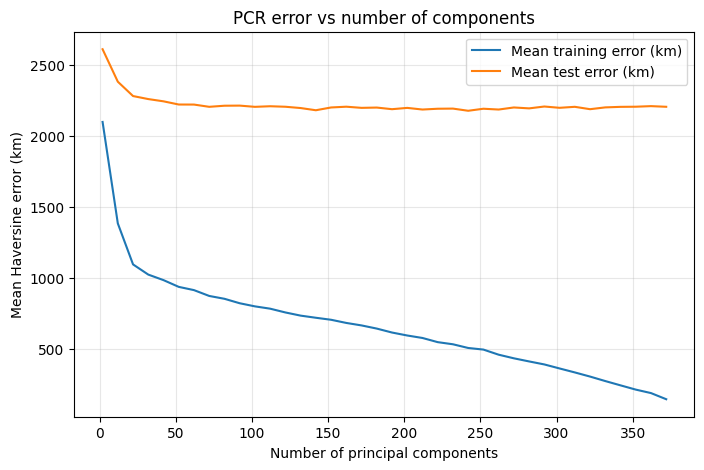

In [18]:
cv = GroupKFold(n_splits=5)
groups = df['Pop']

min_train_samples = min(len(train_idx) for train_idx, _ in cv.split(X, y, groups=groups))
max_valid_components = min(X.shape[1], min_train_samples)
grid = list(range(2, 382, 10))

mean_train_errors_km = []
mean_test_errors_km = []

for n_components in grid:
    pipeline = make_pipeline(PCA(n_components=n_components), sl.LinearRegression())
    # uses parallel processing to speed up the cross-validation by setting n_jobs=-1, use the second line for a deterministic result
    scores = cross_validate(pipeline,X,y,cv=cv,groups=groups,scoring=haversine_km_scorer,return_train_score=True, n_jobs=-1)
    # scores = cross_validate(pipeline,X,y,cv=cv,groups=groups,scoring=haversine_km_scorer,return_train_score=True, n_jobs=1)

    mean_train_errors_km.append(-scores['train_score'].mean())
    mean_test_errors_km.append(-scores['test_score'].mean())

plt.figure(figsize=(8, 5))
plt.plot(grid, mean_train_errors_km, label='Mean training error (km)')
plt.plot(grid, mean_test_errors_km, label='Mean test error (km)')
plt.xlabel('Number of principal components')
plt.ylabel('Mean Haversine error (km)')
plt.title('PCR error vs number of components')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**(e)** Which model would you keep? What is the prediction error for this model? Compare it with its corresponding training error. Plot the predicted coordinates on a map as in **Exercise 4(a)**. What can you conclude?

We observe that the mean test error stops decreasing significantly after approximately $n=50$ components. Therefore, we select this as our optimal model.

In [19]:
best_idx = 5
print(f"Best n_components: {grid[best_idx]}")
print(f"Mean train error (km): {mean_train_errors_km[best_idx]:.2f}")
print(f"Mean test error (km): {mean_test_errors_km[best_idx]:.2f}")

Best n_components: 52
Mean train error (km): 937.19
Mean test error (km): 2223.53


In [20]:
pca = PCA(n_components=grid[best_idx]).fit(X)
Z = pca.transform(X)   
y = df[['long', 'lat']]

# fit a multiple linear regression model
lr = sl.LinearRegression()
lr.fit(Z, y)
prediction = lr.predict(Z)
prediction.shape

(494, 2)

/tmp/ipykernel_16984/3519827205.py:29: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


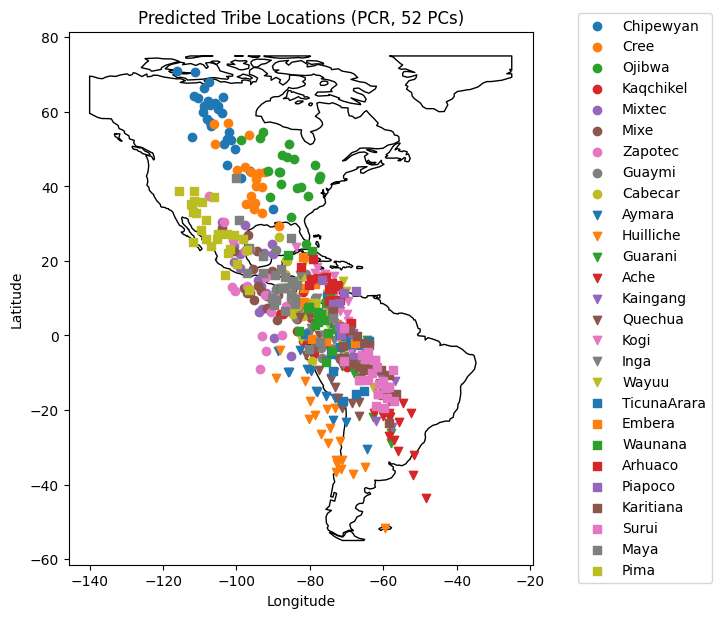

In [21]:
# Plot predicted coordinates
world = gpd.read_file(geodatasets.get_path('naturalearth.land'))
fig, ax = plt.subplots(figsize=(8.0, 6.5))
plt.subplots_adjust(left=0.0, right=0.90, bottom=0.10, top=0.92)
world.clip([-140, -55, -25, 75]).plot(ax=ax, color='white', edgecolor='black')

unique_tribes = df['Pop'].unique()
marker_list = ['o', 'v', 's']
colors_list = [f'C{i}' for i in range(9)]
tribe_styles = {
    tribe: (marker_list[i // 9], colors_list[i % 9])
    for i, tribe in enumerate(unique_tribes)
}

for i in range(len(prediction)):
    tribe = df['Pop'].iloc[i]
    marker, color = tribe_styles[tribe]
    ax.scatter(prediction[i, 0], prediction[i, 1], marker=marker, color=color)

# Build one legend entry per tribe
for tribe in unique_tribes:
    marker, color = tribe_styles[tribe]
    ax.scatter([], [], marker=marker, color=color, label=tribe)

ax.legend(loc='center right', bbox_to_anchor=(1.4, 0.5))
ax.set_title(f'Predicted Tribe Locations (PCR, {grid[best_idx]} PCs)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
fig.show()

We can see that this model performs much worse than the $n=250$ case, as the points are far more dispersed on the map. Furthermore, we know this model does not generalize well to new tribes, given its high mean test error on unseen data.

## ▶️ Exercise 6: Conclusion (2 points)

Propose a conclusion to your study. You can write a paragraph about the quality of predictors versus the number of factors, possible improvements to the approach (for instance, showing what happens when using [partial least squares](https://scikit-learn.org/1.5/auto_examples/cross_decomposition/plot_pcr_vs_pls.html) instead of PCR), comment on the performance of the regression in predictions for each country separately, etc. Note that we expect a thorough presentation of the final predictive model as well as an interpretation of it, not simply a bunch of `python` code lines.

In this study, we used Principal Components Regression (PCR) to predict geographic coordinates from genetic markers. Initial analyses revealed that a very small number of components (e.g., 4) is insufficient, resulting in very high validation errors. As we increase the number of PCA components, the training error decreases continuously, but the test error remains high and relatively flat. This indicates that adding more components primarily improves the model's fit on the training data without substantially enhancing its ability to generalize.

Using grouped cross-validation based on tribes (`GroupKFold`) was essential to prevent data leakage and to simulate a realistic scenario in which we predict the geographic origins of individuals from unseen groups. Under this evaluation strategy, the optimal model in our grid search uses around 50 components. However, the performance gain over neighboring values is marginal compared to the fold-to-fold variability. Consequently, our main conclusion is that the current PCR approach offers limited predictive power for individuals belonging to unseen tribes.

Possible improvements include exploring models that can capture stronger multivariate relationships between genetic markers and geographic coordinates (such as Partial Least Squares, or PLS), employing richer validation strategies, and analyzing the prediction errors by region or tribe to better understand the model's failure modes.